## Background Info on Diabetes

Diabetes is one of the most prevalent chronic diseases in the United States and affects millions of individuals thus placing a significant burden on the healthcare system.

This disease is characterized by the body's inability to properly regulate blood glucose levels, which is either because of insufficient insulin production or reduced insulin sensitivity. Over time, unmanaged diabetes can lead to very serious complications like cardiovascular disease, kidney failure, vision loss, and reduced life expectancy. Because so many individuals are unaware that they are at risk, early identification is important for implementing preventative strategies like lifestyle changes and medical intervention.

The dataset used in this project is derived from the Behavioral Risk Factor Surveillance System (BRFSS), a large scale health survey conducted anually by the CDC. It includes self-reported information on health behaviors, chronic conditions, and demographic factors. The version used in this analysis contains over 70,000 observations and includes key indicators like body mass index (BMI), physical activity, smoking status, and history of conditions like high blood pressure and heart diseases. These variables paint a picture of individual health profiles and are perfect for predictive modeling.

For this analysis, we use a cleaned and preprocessed subset of the data that includes 21 relevant health indicators.

Specifically, we use the balanced binary version of the dataset, which has the target variable indicating whether an individual has diabetes or is at risk (including pre-diabetes). This version was selected over the original multiclass dataset because it provides a balanced class distribution, which improves the performance and interpretability of our classification models. Using a binary outcome also simplifies evaluation metrics and allows for clearer interpretation of results.

## Research Question
The goal of this project is to investigate whether patterns in health-related behaviors and conditions can be used to accurately predict diabetes risk.

So we ask: **Can clustering individuals into health-risk profiles using k-Means improve the performance and interpretability of a kNN model in predicting diabetes?**


To answer this question, we first build a baseline kNN model using the original health indicators. We then optimize the model through hyperparameter tuning. Next, we apply k-Means clustering to identify groups of individuals with similar health characteristics. Finally, we evaluate whether adding cluster membership as an additional feature improves diabetes prediction performance.

## Data Science Lifecycle Phase 1

This part of the project is a part of phase 1, which is where we develop an idea, gather data, bussiness understanding, and evulation criteria. We knew that we wanted our project to focus on something medical, therefore we started formulating questions that we would be interested working on. As we were searching for data sets we realized that most of the health, medicial and hospital data sets were about diseases. We took a look at a few of those before we decided that the diabetes data was the best for our project. This topic is interesting to us and as we looked over the data set we quickly saw that we would be able to use kMeans clustering and kNN models to try and predict whether there are any variables that could help us predict diabetes for individuals.


In [1]:
# IMPORTS:
# from sklearn.datasets import load_diabetes
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Sklearn - preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    roc_auc_score
)

# For cluster evaluation
from sklearn.metrics import silhouette_score

In [2]:
# Importing our dataset
# using: diabetes_binary_5050split_health_indicators_BRFSS2015.csv

# Reason:
# 1. Binary classification (0 = no diabetes, 1 = prediabetes/diabetes)
# 2. Balanced dataset (50/50 split)
# 3. Better for kNN and evaluation (accuracy, ROC-AUC)

df = pd.read_csv("diabetes_binary_5050split_health_indicators_BRFSS2015.csv")

# Exploratory Data Analysis

In [3]:
# View dataset dimensions (rows, columns)
df.shape

(70692, 22)

In [4]:
# Preview first few rows to understand structure
df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0


In [5]:
# Display column names, data types, and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 70692 entries, 0 to 70691
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Diabetes_binary       70692 non-null  float64
 1   HighBP                70692 non-null  float64
 2   HighChol              70692 non-null  float64
 3   CholCheck             70692 non-null  float64
 4   BMI                   70692 non-null  float64
 5   Smoker                70692 non-null  float64
 6   Stroke                70692 non-null  float64
 7   HeartDiseaseorAttack  70692 non-null  float64
 8   PhysActivity          70692 non-null  float64
 9   Fruits                70692 non-null  float64
 10  Veggies               70692 non-null  float64
 11  HvyAlcoholConsump     70692 non-null  float64
 12  AnyHealthcare         70692 non-null  float64
 13  NoDocbcCost           70692 non-null  float64
 14  GenHlth               70692 non-null  float64
 15  MentHlth              70692 no

In [6]:
# Double checking there's no null values
df.isnull().sum()

Diabetes_binary         0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

In [7]:
# Summary statistics for all variables
df.describe()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,...,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000
mean,0.500000,0.563458,0.525703,0.975259,29.856985,0.475273,0.062171,0.147810,0.703036,0.611795,...,0.954960,0.093914,2.837082,3.752037,5.810417,0.252730,0.456997,8.584055,4.920953,5.698311
std,0.500004,0.495960,0.499342,0.155336,7.113954,0.499392,0.241468,0.354914,0.456924,0.487345,...,0.207394,0.291712,1.113565,8.155627,10.062261,0.434581,0.498151,2.852153,1.029081,2.175196
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,7.000000,4.000000,4.000000
50%,0.500000,1.000000,1.000000,1.000000,29.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,9.000000,5.000000,6.000000
75%,1.000000,1.000000,1.000000,1.000000,33.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,4.000000,2.000000,6.000000,1.000000,1.000000,11.000000,6.000000,8.000000
max,1.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


**Interpretation**

The dataset contains 70,692 observations and 22 variables, including the target variable Diabetes_binary. All variables are numeric, with most representing binary indicators (0 or 1), while a few variables such as BMI, Age, GenHlth, MentHlth, and PhysHlth are continuous or ordinal.

There are no missing values in the dataset, which simplifies our preprocessing. The target variable has a mean of 0.5, confirming that the dataset is balanced between individuals with and without diabetes risk.

This balance is really good for  classification models because it prevents bias towards one class.

In [8]:
# Convert all columns to integer type

# Some variables are binary but stores as floats
# Converting to integer will ensure consistency across features

df = df.astype(int)

# Confirm updates data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 70692 entries, 0 to 70691
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Diabetes_binary       70692 non-null  int64
 1   HighBP                70692 non-null  int64
 2   HighChol              70692 non-null  int64
 3   CholCheck             70692 non-null  int64
 4   BMI                   70692 non-null  int64
 5   Smoker                70692 non-null  int64
 6   Stroke                70692 non-null  int64
 7   HeartDiseaseorAttack  70692 non-null  int64
 8   PhysActivity          70692 non-null  int64
 9   Fruits                70692 non-null  int64
 10  Veggies               70692 non-null  int64
 11  HvyAlcoholConsump     70692 non-null  int64
 12  AnyHealthcare         70692 non-null  int64
 13  NoDocbcCost           70692 non-null  int64
 14  GenHlth               70692 non-null  int64
 15  MentHlth              70692 non-null  int64
 16  PhysHlth       

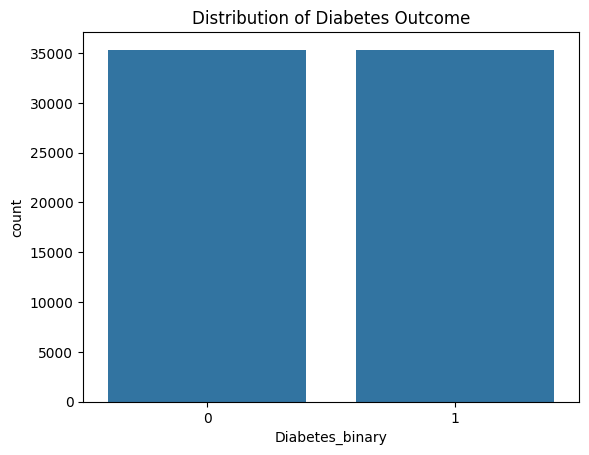

In [9]:
# Target Variable Distribution

# Visualization distribution of target variable

# Count of each class ( 0 = no diabetes & 1 = diabetes/prediabetes)
sns.countplot(x="Diabetes_binary", data=df)

# Adds title
plt.title("Distribution of Diabetes Outcome")

# Displays plot
plt.show()

**Interpretation**

The target variable is evenly distributed between the two classes, confirming that the dataset is balanced. This is important because it allows classification models to learn both classes equally and ensures that evaluation metrics such as accuracy and ROC-AUC are meaningful.

## BMI and Diabetes Relationship

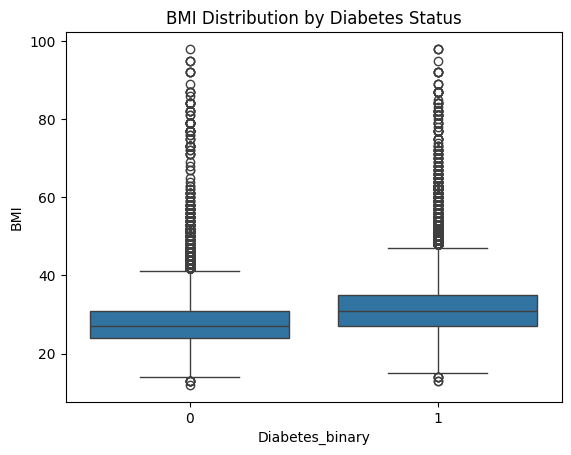

In [10]:
# Analyze relationship between BMI and diabetes
# This plot compares the distribution of BMI between individuals
# with and without diabetes risk.

# Boxplot comparing BMI distributions across diabetes classes
sns.boxplot(x='Diabetes_binary', y='BMI', data=df)

# Add title
plt.title("BMI Distribution by Diabetes Status")

# Display plot
plt.show()

**Interpretation**

The distribution shows that individuals with diabetes (class 1) tend to have higher BMI values compared to those without diabetes (class 0). The median BMI for the diabetes group is noticeably higher, and the upper range of BMI values is also more extreme.

There is also a wider spread in BMI among individuals with diabetes, suggesting greater variability in this group. While both groups contain outliers, the concentration of higher BMI values is more prominent in the diabetes group.

This supports the established relationship between obesity and diabetes risk, indicating that BMI is likely to be a strong predictor in the model.

## Age and Diabetes Relationship

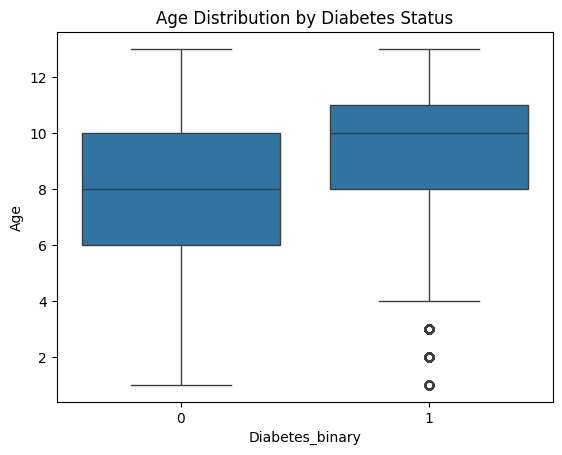

In [11]:
# Analyze relationship between Age and diabetes
# This plot compares the distribution of age categories
# between individuals with and without diabetes risk.

# Boxplot comparing Age across diabetes classes
sns.boxplot(x='Diabetes_binary', y='Age', data=df)

# Add title
plt.title("Age Distribution by Diabetes Status")

# Display plot
plt.show()

**Interpretation**

Individuals with diabetes tend to fall into higher age categories compared to those without diabetes. The median age for the diabetes group is higher, and the distribution is shifted upward overall.

This indicates that age is an important factor in diabetes risk. However, since age is encoded in categories rather than exact values, the interpretation reflects relative age group differences rather than precise age differences.

The presence of some lower-age outliers in the diabetes group suggests that while age is a strong factor, diabetes can still occur in younger individuals.

## Physical Activity and Diabetes

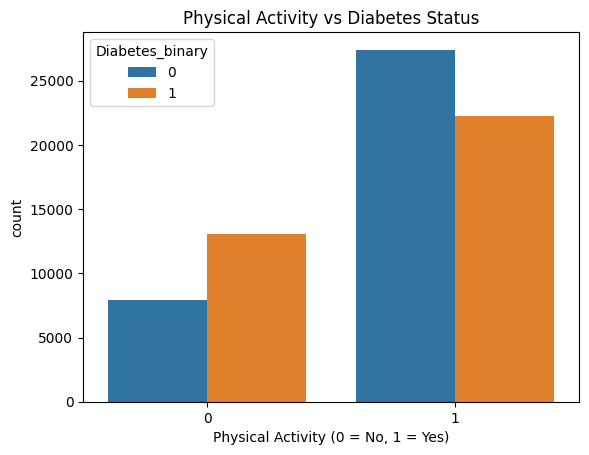

In [12]:
# Analyze physical activity vs diabetes

# This plot compares the number of individuals who report
# physical activity (1) vs no physical activity (0),
# separated by diabetes status.


# Countplot with hue to compare diabetes status
sns.countplot(x='PhysActivity', hue='Diabetes_binary', data=df)

# Adds title
plt.title("Physical Activity vs Diabetes Status")

# Adds x-axis label
plt.xlabel("Physical Activity (0 = No, 1 = Yes)")

# Displays plot
plt.show()

**Interpretation**

The plot shows that individuals who report no physical activity (PhysActivity = 0) have a higher proportion of diabetes compared to those who are physically active. While both groups contain individuals with and without diabetes, the relative frequency of diabetes is noticeably higher among those who are inactive.

This suggests that physical inactivity is associated with increased diabetes risk. However, since a substantial number of physically active individuals also have diabetes, physical activity alone is not sufficient to fully explain the outcome. This reinforces the need for models that consider multiple features simultaneously.

## High Blood Pressure and Diabetes

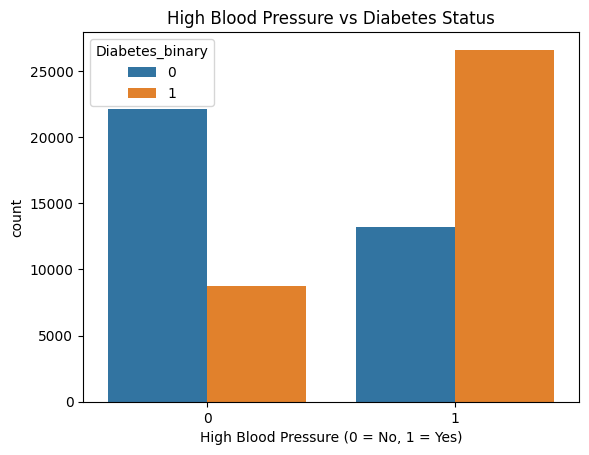

In [13]:
# Analyze high blood pressure vs diabetes

# This plot compares individuals with and without high blood pressure,
# separated by diabetes status.
sns.countplot(x='HighBP', hue='Diabetes_binary', data=df)

# Adds title and x-axis lavel
plt.title("High Blood Pressure vs Diabetes Status")
plt.xlabel("High Blood Pressure (0 = No, 1 = Yes)")

# Shows plot
plt.show()

**Interpretation**

The distribution shows a strong association between high blood pressure and diabetes. Individuals with high blood pressure (HighBP = 1) are much more likely to have diabetes compared to those without high blood pressure.

In contrast, among individuals without high blood pressure, the majority do not have diabetes. This indicates that high blood pressure is one of the strongest predictors observed so far and is likely to play an important role in the classification model.

## General Health and Diabetes

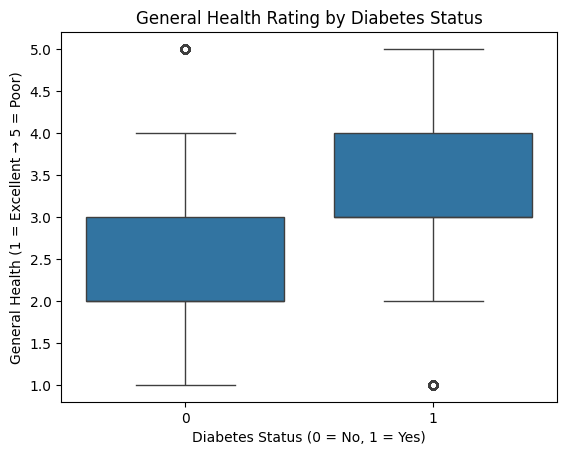

In [14]:
# Analyze general health (ordinal) vs diabetes

# GenHlth is an ordinal variable:
# 1 = Excellent, 2 = Very Good, 3 = Good, 4 = Fair, 5 = Poor

# This plot shows how general health ratings differ
# between individuals with and without diabetes.
sns.boxplot(x='Diabetes_binary', y='GenHlth', data=df)


# Add labels and title
plt.title("General Health Rating by Diabetes Status")
plt.xlabel("Diabetes Status (0 = No, 1 = Yes)")
plt.ylabel("General Health (1 = Excellent → 5 = Poor)")

# Displays plot
plt.show()

**Interpretation**

The distribution shows that individuals with diabetes tend to report worse general health compared to those without diabetes. The median for the diabetes group is higher (closer to “fair” or “poor”), while the non-diabetes group is centered around better health ratings.

There is also a noticeable upward shift in the entire distribution for individuals with diabetes, indicating that poorer self-reported health is strongly associated with diabetes status. This aligns with earlier findings (BMI, HighBP), reinforcing that diabetes is closely tied to overall health condition rather than a single isolated factor.

## Correlation Analysis

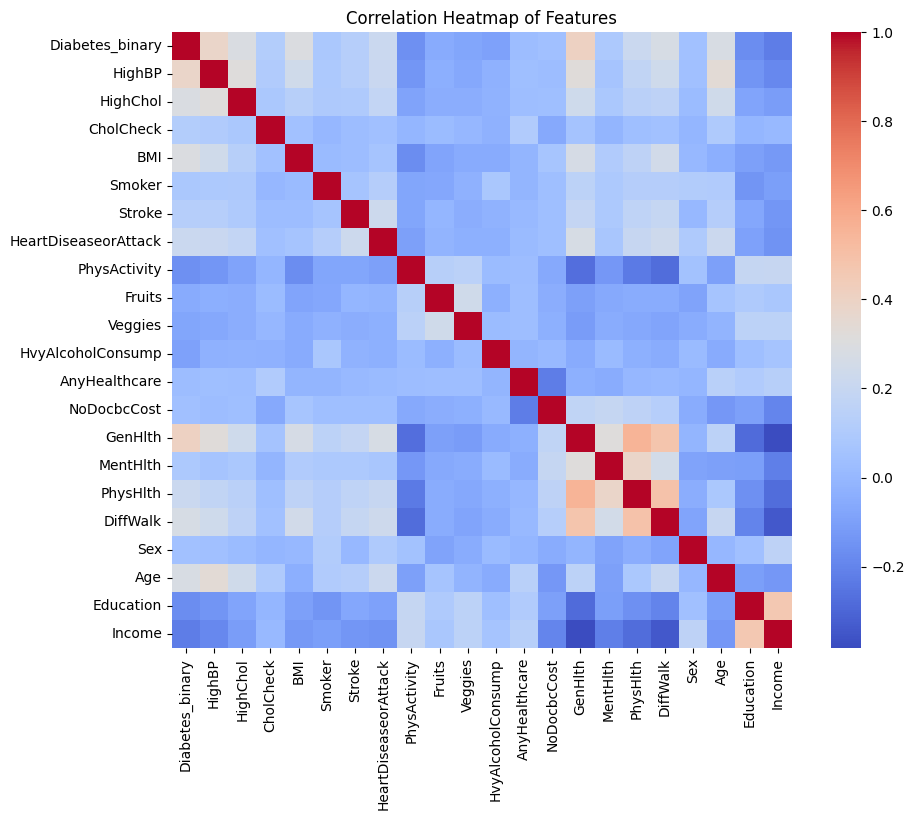

In [15]:
# Correlation heatmap

# Compute correlation matrix
corr_matrix = df.corr()

# Plots heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap='coolwarm')

plt.title("Correlation Heatmap of Features")

# Displays plot
plt.show()

**Interpretation**

The heatmap shows the pairwise correlations between all variables in the dataset.

Key observations:

Diabetes_binary shows moderate positive correlations with:

*   HighBP
*   BMI
*   GenHlth
*   Age

There are also noticeable relationships among health-related variables:
GenHlth, PhysHlth, and DiffWalk are

*   GenHlth, PhysHlth, and DiffWalk are positively correlated, suggesting they capture related aspects of overall health condition
*   Income and Education show positive correlation, reflecting socioeconomic structure

Most correlations are relatively low, indicating that no single feature dominates prediction.

## EDA Summary

The exploratory data analysis reveals several patterns associated with diabetes. Individuals with diabetes tend to have higher BMI, are older, are more likely to have high blood pressure, and report worse general health. Behavioral factors such as physical activity also show an association, with inactive individuals exhibiting higher rates of diabetes.

While several variables demonstrate clear relationships with diabetes, none alone is sufficient to fully explain the outcome. The correlation heatmap further supports this, showing that most features have only moderate or weak pairwise correlations with the target variable.

Overall, these findings suggest that diabetes is influenced by a combination of demographic, behavioral, and clinical factors. This motivates the use of k-nearest neighbors for classification and k-means for clustering, to capture these multivariate relationships and improve predictive performance.

## Data Science Lifecycle Phase 2

The EDA phase is a part of phase 2 where we get to know our data set. We look over the data to ensure that there are no missing values and we costumize our data to best suit our project question. For this data set we did not have to drop a few columns because we can just chose which ones we will be using for initial model building. The only change made to the actual data was to have an orginized structure, where all binary values were made integers.  



# Modeling Preparation/ Methods

After completing exploratory data analysis, we identified several variables that appear to be associated with diabetes risk, including BMI, age, physical activity, high blood pressure, and general health. While EDA helped us understand individual relationships between variables and diabetes, it does not allow us to make predictions on unseen individuals.

The purpose of this phase is to prepare our dataset for machine learning models by separating our predictors from our target variable and creating training and testing datasets. This ensures that our models are evaluated on unseen data, which gives a more realistic measure of performance.

We use an 80/20 train-test split:

Training data → used to train models and tune hyperparameters

Testing data → used only for final evaluation

This prevents overfitting and allows us to assess how well our model generalizes to new observations.

In [16]:
# Modeling Preparation

# Separate features from the target variable.
# X contains the health indicator variables.
# y contains the diabetes outcome.
X = df.drop(columns=['Diabetes_binary'])
y = df['Diabetes_binary']

# Split the data into training and testing sets.
# stratify=y keeps the 50/50 diabetes class balance in both train and test sets.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Check the shape of each split to confirm the data was separated correctly.
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (56553, 21)
X_test shape: (14139, 21)
y_train shape: (56553,)
y_test shape: (14139,)


# Model 1: Baseline k-Nearest Neighbors (kNN)

Question:
Can the original health features predict diabetes at all?

What we're doing: Using only the original 21 health indicators: BMI, HighBP, Age, GenHlth, etc.



**Why we are doing this:**

This model serves as our baseline classification model. We use kNN because it works well for classification problems involving multiple features.

kNN classifies an observation by looking at the most similar neighboring observations and assigning the most common class.

Since kNN relies on distance calculations:

- variables must be scaled
- larger-scale variables like BMI could dominate the model if scaling is not applied

This baseline model helps establish an initial performance benchmark before tuning/adding clustering features.

Model 1: Baseline kNN Without Clusters
Accuracy: 0.712850979560082

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.69      0.71      7070
           1       0.70      0.74      0.72      7069

    accuracy                           0.71     14139
   macro avg       0.71      0.71      0.71     14139
weighted avg       0.71      0.71      0.71     14139



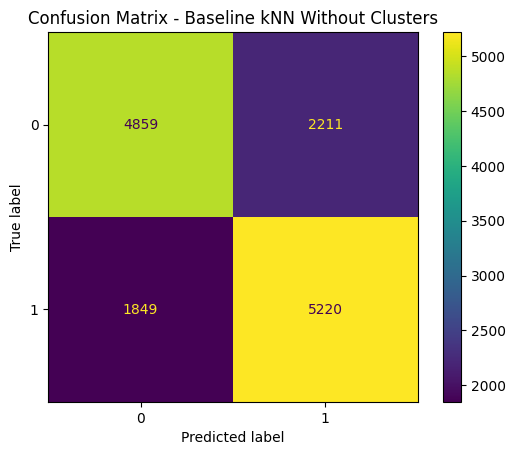

In [17]:
# Model 1: Baseline kNN without clusters

# This pipeline first scales the data, then fits a kNN classifier.
# Scaling is necessary because kNN is distance-based.
knn_baseline_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])

# Fit the baseline model on the training data only.
knn_baseline_pipeline.fit(X_train, y_train)

# Predict diabetes status for the unseen test data.
y_pred_baseline = knn_baseline_pipeline.predict(X_test)

# Evaluate baseline model performance.
print("Model 1: Baseline kNN Without Clusters")
print("Accuracy:", accuracy_score(y_test, y_pred_baseline))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_baseline))

# Display confusion matrix.
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_baseline)
plt.title("Confusion Matrix - Baseline kNN Without Clusters")
plt.show()

### Model 1 Interpretation:

Model 1 serves as our baseline kNN classifier using the original 21 health indicator variables without any clustering features. The model achieved an accuracy of approximately 71.3% on the test set.

The classification report shows that performance is fairly balanced across both classes. For individuals without diabetes, the model had a precision of 0.72 and recall of 0.69. For individuals with diabetes, the model had a precision of 0.70 and recall of 0.74. This means the model was slightly better at identifying individuals with diabetes than individuals without diabetes.

This baseline result gives us a reference point for later models. Any tuning or clustering approach should be compared against this performance to determine whether it meaningfully improves prediction.

# Model 2: Tuned kNN Without Clusters

Question:
Can we make our original kNN model better?

What we're doing: Still using the same original 21 features BUT now we're optimizing: number of neighbors & weighting method using GridSearchCV

This is just improving Model 1.

Model 2 improves on the baseline kNN model by tuning the model’s hyperparameters. In Model 1, we used k = 5 neighbors by default. However, this may not be the best value for our data.

Here, we use GridSearchCV to test different values of n_neighbors and different weighting methods. This allows us to compare several versions of kNN using cross-validation on the training data only.

Best Parameters: {'knn__n_neighbors': 21, 'knn__weights': 'uniform'}
Best Cross-Validation Accuracy: 0.7364065230430289
Model 2: Tuned kNN Without Clusters
Accuracy: 0.7322300021217908

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.69      0.72      7070
           1       0.71      0.77      0.74      7069

    accuracy                           0.73     14139
   macro avg       0.73      0.73      0.73     14139
weighted avg       0.73      0.73      0.73     14139



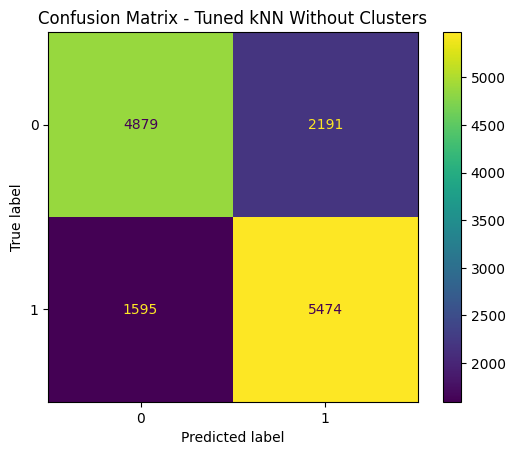

In [18]:
# Model 2: Tuned kNN without clusters

# Create a pipeline that first scales the data and then fits a kNN model
# Scaling is necessary because kNN uses distance calculations
knn_tuned_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

# Define the hyperparameters we want to test
# n_neighbors controls how many nearby points are used for voting
# weights controls whether each neighbor counts equally or closer neighbors count more
param_grid = {
    'knn__n_neighbors': [3, 5, 7, 9, 11, 15, 21],
    'knn__weights': ['uniform', 'distance']
}

# GridSearchCV tests each parameter combination using cross-validation
# This tuning happens only on the training data to avoid data leakage
grid_search = GridSearchCV(
    knn_tuned_pipeline,
    param_grid,
    cv=5,
    scoring='accuracy'
)

# Fit the grid search on the training data
grid_search.fit(X_train, y_train)

# Print the best parameters and cross-validation score
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

# Store the best model found by GridSearchCV
best_knn_model = grid_search.best_estimator_

# Use the tuned model to predict diabetes status for the test set
y_pred_tuned = best_knn_model.predict(X_test)

# Evaluate tuned model performance
print("Model 2: Tuned kNN Without Clusters")
print("Accuracy:", accuracy_score(y_test, y_pred_tuned))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned))

# Display confusion matrix for the tuned kNN model
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_tuned)
plt.title("Confusion Matrix - Tuned kNN Without Clusters")
plt.show()

### Model 2 Interpretation

Model 2 improved upon the baseline kNN model by tuning the number of neighbors and weighting method through GridSearchCV. The best-performing model used 21 neighbors with uniform weighting, achieving a cross-validation accuracy of approximately 73.6%.

When evaluated on the test set, the tuned model achieved an accuracy of 73.2%, improving performance by nearly 2 percentage points compared to the baseline model.

The classification report shows stronger overall performance across both classes. Most notably, recall for individuals with diabetes increased to 77%, meaning the model correctly identified a larger proportion of individuals who were at risk.

This improvement suggests that tuning the model’s hyperparameters helped reduce noise and improved generalization. Since this model currently performs better than the baseline model, it becomes the strongest classification benchmark before introducing clustering features.

# Model 3: K-Means Clustering

Question: Are there natural health-risk groups in the dataset?

What we’re doing:
- This is NOT predicting diabetes yet.
- We're grouping people based on similarities in health characteristics.

Example:

Cluster might represent:
- high BMI
- poor health
- older age

Another cluster:
- healthier people, etc

So the PURPOSE is to create new information (cluster labels)

Thus,

After improving our classification model through hyperparameter tuning, we wanted to explore whether unsupervised learning could identify meaningful health-risk groups within the dataset.

K-Means clustering groups individuals based on similarity across multiple health indicators. Rather than looking at variables individually, clustering helps identify broader health profiles that may reveal hidden patterns related to diabetes risk.

If these clusters capture meaningful patterns, adding clusters as a feature may improve our final classification model.

In [19]:
# Step 1: Scaling training/testing data for clustering

# Prepare data for K-Means clustering

# Create a new scaler for clustering.
# We fit ONLY on training data to avoid data leakage.
scaler = StandardScaler()

# Fit scaler on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using training scaler
X_test_scaled = scaler.transform(X_test)

# Check shapes
print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape:", X_test_scaled.shape)

Scaled training shape: (56553, 21)
Scaled testing shape: (14139, 21)


### Step 2: Elbow Plot

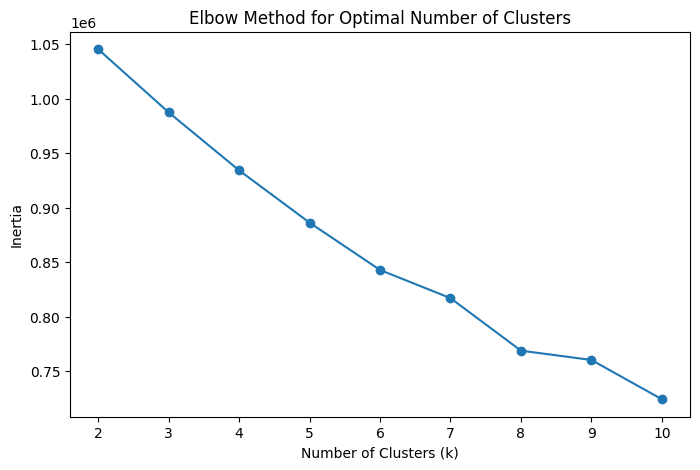

In [20]:
# Step 2: Elbow Method
# this will help determine the best number of clusters

# Store inertia values for different k values
inertias = []

# Test cluster values from 2 to 10
k_values = range(2, 11)

# Fit K-Means for each k value
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42,n_init=10)
    kmeans.fit(X_train_scaled)
    inertias.append(kmeans.inertia_)

# Plot elbow curve
plt.figure(figsize=(8,5))
# Plots the range for 'k_values' and the ideal number of kmeans clusters
plt.plot(k_values, inertias, marker='o')

#shows x-label
plt.xlabel("Number of Clusters (k)")
#shows y-label
plt.ylabel("Inertia")
#shows title
plt.title("Elbow Method for Optimal Number of Clusters")

#shows graph
plt.show()

**Elbow Plot Explanation**

The elbow method was used to determine an appropriate number of clusters for the K-Means model. As expected, inertia decreases as the number of clusters increases because observations become closer to their assigned cluster centers.

The largest decreases occur between k = 2 and k = 6, after which the rate of improvement begins to slow. The curve begins to flatten around k = 8, and moving from 8 to 9 clusters produces only minimal improvement.

Based on this, we selected k = 8.

### Step 3: Fit final K-Means model; k = 8

In [21]:
# Final K-Means Model

# Fit final K-Means model using k = 8
kmeans_final = KMeans(
    n_clusters=8,
    random_state=42,
    n_init=10
)

# Fit clusters on training data only
train_clusters = kmeans_final.fit_predict(X_train_scaled)

In [22]:
# Predict cluster membership for test data
test_clusters = kmeans_final.predict(X_test_scaled)

# Convert scaled arrays back into DataFrames
X_train_scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled_df = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

### Step 4: Cluster sizes

In [23]:
# Add cluster labels as a new feature
X_train_clustered = X_train_scaled_df.copy()
X_test_clustered = X_test_scaled_df.copy()

X_train_clustered['Diabetes_clusters'] = train_clusters
X_test_clustered['Diabetes_clusters'] = test_clusters

# Check cluster sizes
print("Training Cluster Sizes:")
print(X_train_clustered['Diabetes_clusters'].value_counts().sort_index())

Training Cluster Sizes:
Diabetes_clusters
0     2225
1    15010
2     2179
3     8978
4     3285
5    16400
6     7092
7     1384
Name: count, dtype: int64


**Interpretation:**

The cluster sizes are not perfectly equal, which is expected because K-Means identifies naturally occurring groupings rather than forcing evenly sized clusters.

The largest clusters contain over 15,000 observations, while the smallest cluster contains approximately 1,400 observations. Since even the smallest cluster remains large enough for analysis, all clusters were retained for interpretation.

### Step 5: Interpret cluster profiles

In [24]:
# Cluster Profile Analysis

# Create a copy of original training data
cluster_summary = X_train.copy()

# Add cluster labels
cluster_summary['Diabetes_clusters'] = train_clusters

# Add target variable for interpretation
cluster_summary['Diabetes_binary'] = y_train

# Calculate average values for each cluster
cluster_means = cluster_summary.groupby('Diabetes_clusters').mean()

# View all cluster averages
cluster_means

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
Diabetes_clusters,,,,,,,,,,,,,,,,,,,,,
0,0.507416,0.474607,1.0,30.539326,0.491685,0.041348,0.120899,0.640000,0.552809,0.732584,...,0.399551,3.047640,5.470562,6.061124,0.238652,0.464719,6.858427,4.377528,4.374831,0.479551
1,0.077149,0.224983,1.0,27.049367,0.306129,0.000533,0.012258,0.878614,0.715723,0.954564,...,0.049833,2.036043,1.987275,1.494071,0.026915,0.409061,6.788741,5.380213,6.875083,0.186276
2,0.510785,0.474989,1.0,27.775126,0.656264,0.025700,0.083525,0.748508,0.552088,0.843965,...,0.077559,2.476824,4.079853,3.738412,0.138137,0.489215,7.922900,5.128040,6.546581,0.279945
3,0.761528,0.688572,1.0,33.676654,0.595790,0.000000,0.293050,0.417242,0.543440,0.772778,...,0.197594,4.102361,10.764424,20.069392,0.819448,0.339162,9.143016,4.396970,3.980842,0.765092
4,0.814916,0.731202,1.0,30.583257,0.596043,1.000000,0.460578,0.554642,0.599391,0.714155,...,0.122983,3.673364,6.469711,12.305023,0.583866,0.465753,10.039878,4.631355,4.563775,0.757686
5,0.862500,0.686707,1.0,30.334268,0.509268,0.000000,0.161341,0.763232,0.679695,1.000000,...,0.036829,2.762622,1.363476,2.284146,0.144085,0.517195,9.909024,4.982561,5.985000,0.623598
6,0.626340,0.571066,1.0,30.307107,0.483221,0.000000,0.118302,0.619994,0.378878,0.000705,...,0.059645,2.815849,2.004935,2.687253,0.167372,0.547800,9.045544,4.671038,5.440919,0.567682
7,0.241329,0.257225,0.0,27.873555,0.492775,0.028902,0.049133,0.731214,0.552746,0.789017,...,0.206647,2.429191,4.222543,3.660405,0.133671,0.476879,6.739162,4.969653,5.601879,0.139451


In [25]:
# Focus on most important variables

important_features = [
    'BMI',
    'HighBP',
    'HighChol',
    'PhysActivity',
    'GenHlth',
    'Age',
    'DiffWalk',
    'Diabetes_binary'
]

cluster_means[important_features]

,BMI,HighBP,HighChol,PhysActivity,GenHlth,Age,DiffWalk,Diabetes_binary
Diabetes_clusters,,,,,,,,
0,30.539326,0.507416,0.474607,0.640000,3.047640,6.858427,0.238652,0.479551
1,27.049367,0.077149,0.224983,0.878614,2.036043,6.788741,0.026915,0.186276
2,27.775126,0.510785,0.474989,0.748508,2.476824,7.922900,0.138137,0.279945
3,33.676654,0.761528,0.688572,0.417242,4.102361,9.143016,0.819448,0.765092
4,30.583257,0.814916,0.731202,0.554642,3.673364,10.039878,0.583866,0.757686
5,30.334268,0.862500,0.686707,0.763232,2.762622,9.909024,0.144085,0.623598
6,30.307107,0.626340,0.571066,0.619994,2.815849,9.045544,0.167372,0.567682
7,27.873555,0.241329,0.257225,0.731214,2.429191,6.739162,0.133671,0.139451


**Cluster Interpretation:**

The cluster analysis revealed meaningful differences in health-risk profiles across individuals.

Clusters 3 and 4 represented the highest-risk groups, with diabetes rates above 75%. These clusters were characterized by higher BMI, high rates of high blood pressure and cholesterol, older age groups, poorer general health, and greater difficulty walking.

In contrast, Clusters 1 and 7 represented lower-risk groups. These individuals tended to have lower BMI, lower rates of high blood pressure, better general health, higher physical activity levels, and substantially lower diabetes prevalence.

These findings suggest that the clustering model successfully identified meaningful health profiles that may provide additional predictive value in the final classification model.

### Step 6: 3D Visualization

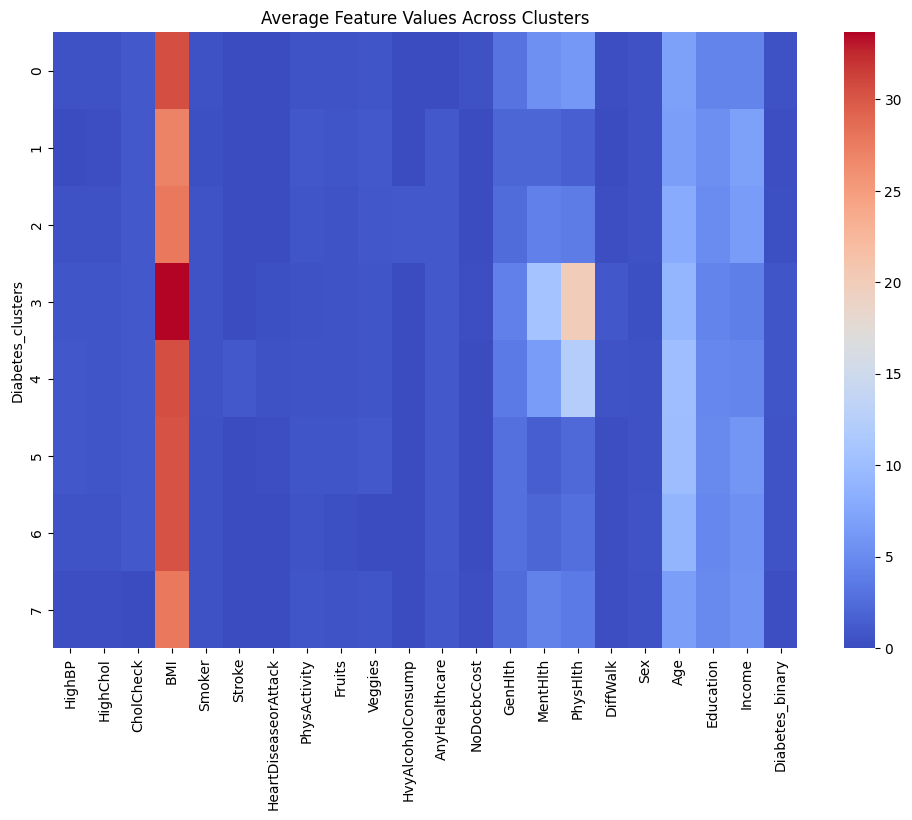

In [26]:
#Make a heatmap to see the feature values across clusters

#heatmap size
plt.figure(figsize=(12,8))

#makes the heatmap
sns.heatmap(cluster_means, cmap='coolwarm')

#adds the title
plt.title("Average Feature Values Across Clusters")

#shows the heatmap
plt.show()

## Data Science Lifecycle Phase 3
This phase includes the development of our solution. So far we have created our kMeans model, that clusters our data into 8 clusters because our elbow plot started to flatten after this value. We have chosen 21 features to be used by the kMeans algorithm to group individuals with similar patterns into the same cluster. We are doing this so the model can identify patterns within the dataset, such as groups of individuals who share similar risk factors for diabetes. In doing this we are organizing the dataset into 8 clusters based on these features, this can create groupings that would later be used as an additional feature in our supervised learning models.

# Model 4: Tuned kNN with Cluster Labels

Question: Do those clusters improve prediction?

What we’re doing:

Taking our original 21 features PLUS **Diabetes_clusters**

Then running our best kNN model from Model 2 again.

Purpose: testing our actual research question.

Thus,

After identifying meaningful health-risk groups through K-Means clustering, the final step of our project is to determine whether these clusters improve diabetes prediction.

In Model 2, we developed our strongest classification model using the original health indicators and achieved an accuracy of 73.24%. In Model 3, we used K-Means clustering to identify groups of individuals with similar health profiles, such as higher-risk and lower-risk populations.

Now, we combine both approaches by adding cluster membership as an additional feature in our kNN model. This allows us to test whether these health-risk profiles provide new information beyond the original variables.

This is the most important stage of the project because it answers our research question: **Can clustering individuals into health-risk profiles improve diabetes prediction?**

Model 4: Tuned kNN With Cluster Labels
Accuracy: 0.7331494447980762

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.68      0.72      7070
           1       0.71      0.78      0.75      7069

    accuracy                           0.73     14139
   macro avg       0.74      0.73      0.73     14139
weighted avg       0.74      0.73      0.73     14139



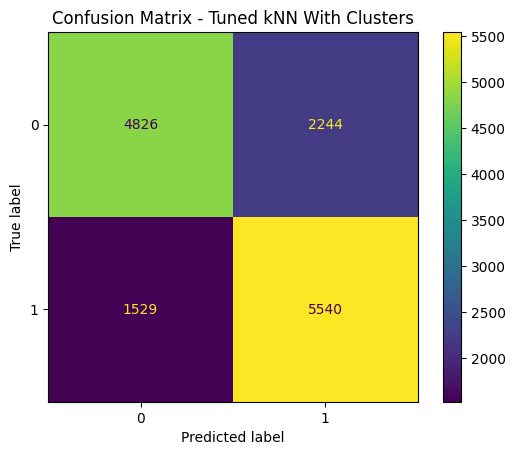

In [27]:
# Model 4: Tuned kNN with Cluster Labels - SUPERVISED Learning

# Use the best parameters found from Model 2
knn_cluster_model = KNeighborsClassifier(
    n_neighbors=grid_search.best_params_['knn__n_neighbors'],
    weights=grid_search.best_params_['knn__weights']
)

# Train the model using original features + cluster labels
knn_cluster_model.fit(X_train_clustered, y_train)

# Predict on test set
y_pred_clustered = knn_cluster_model.predict(X_test_clustered)

# Evaluate performance
print("Model 4: Tuned kNN With Cluster Labels")
print("Accuracy:", accuracy_score(y_test, y_pred_clustered))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_clustered))

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_clustered)
plt.title("Confusion Matrix - Tuned kNN With Clusters")
plt.show()

**Interpretation:**

After identifying health-risk clusters through K-Means, cluster membership was added as an additional feature in the final kNN model.

The final model achieved an accuracy of 73.34%, which was slightly higher than the tuned kNN model without clusters (73.24%).

While the improvement in overall accuracy was small, the cluster-enhanced model reduced false negatives from 1,595 to 1,529. This means the model missed fewer individuals who actually had diabetes, which is particularly important in a healthcare setting where failing to identify at-risk individuals can have serious consequences.

Additionally, recall for the diabetes class improved from 77% to 78%.

These results suggest that clustering provided useful health-risk segmentation, but most predictive power was already captured by the original health indicators.

## Data Science Lifecycle Phase 4
This phase is our solution deployment, for our final model we created a kNN model with our kMeans clusters to test the effectiveness of our algorithm and to answer our question. This allows the model to use both the original features and the cluster groupings to improve prediction performance. Testing this final model is important because it allows us to compare its performance against earlier models and determine whether adding cluster information improves our accuracy and overall predictive ability of diabietes. This final evaluation allows us to ensure that the methods and models we created throughout the project all contribute meaningfully to improving our results and answering our overall question.

In [28]:
# Final Model Comparison Table

model_results = pd.DataFrame({
    'Model': [
        'Baseline kNN',
        'Tuned kNN',
        'Tuned kNN + Clusters'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_baseline),
        accuracy_score(y_test, y_pred_tuned),
        accuracy_score(y_test, y_pred_clustered)
    ]
})

model_results

,Model,Accuracy
0,Baseline kNN,0.712851
1,Tuned kNN,0.732230
2,Tuned kNN + Clusters,0.733149


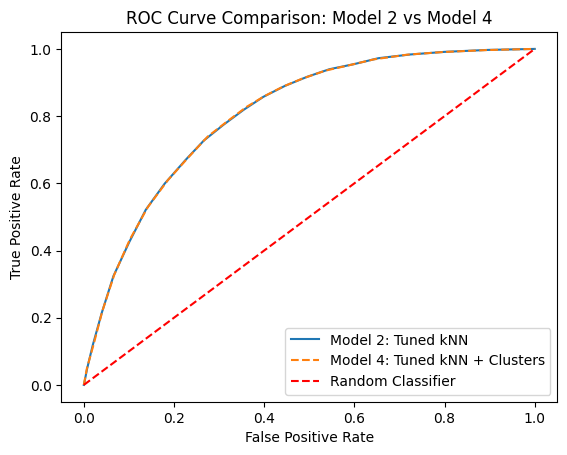

Model 2 AUC: 0.8075
Model 4 AUC: 0.8074


In [29]:
# ROC Curve Comparison: Model 2 vs Model 4

# Get predicted probabilities for both models
y_prob_tuned = best_knn_model.predict_proba(X_test)[:, 1]
y_prob_clustered = knn_cluster_model.predict_proba(X_test_clustered)[:, 1]

# Calculate ROC curves
fpr_tuned, tpr_tuned, _ = roc_curve(y_test, y_prob_tuned)
fpr_clustered, tpr_clustered, _ = roc_curve(y_test, y_prob_clustered)

# Calculate AUC scores
auc_tuned = roc_auc_score(y_test, y_prob_tuned)
auc_clustered = roc_auc_score(y_test, y_prob_clustered)

# Plot both curves on the same graph
plt.plot(fpr_tuned, tpr_tuned, label=f'Model 2: Tuned kNN')
plt.plot(fpr_clustered, tpr_clustered, label=f'Model 4: Tuned kNN + Clusters',linestyle="dashed")
plt.plot([0, 1], [0, 1],'r--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison: Model 2 vs Model 4')
plt.legend()
plt.show()

# AUC Scores for both models
print(f"Model 2 AUC: {auc_tuned:.4f}")
print(f"Model 4 AUC: {auc_clustered:.4f}")

**Interpretation:**

Both models, Model 2 and Model 4, perform better than the random classifier, with AUC scores of 0.8075 for Model 2 and 0.8074 for Model 4. The AUC scores indicate that the models can reliably differentiate between individuals with and without diabetes across different classification thresholds. The two curves, indicated in blue for Model 2 and dashed orange for Model 4, are closely related, suggesting that adding K-Means cluster labels as a feature did not significantly improve how the model ranks predictions in terms of the probability the model would correctly rank the diabetes cases higher than the non-diabetes cases.

# Conclusion
We decided to use a kNN model because it is effective for classification problems where similarity between individuals is significant. And we thought that adding kMeans clustering would allow us to group individuals with similar health features, which in turn creates a new feature that represents unseen population patterns. This hybrid method was chosen to test whether unsupervised learning could improve the results of supervised learning.

As a result of our final model, ROC and AUC scores we can gather that our question was going in the right direction. Our goal was to determine whether adding kMeans clusters to a kNN model would improve the accuracy of the model in predicting whether someone has diabietes or not. The results show that there was a small difference in the accuracy of the kNN models.

The kMeans clusters brought the model to an improvement of accuracy. The kNN basline model was 0.713 accurate, the kNN tuned model accuracy score was 0.732 accurate and our kNN with clusters model got an accuracy of 0.733. The ROC curves for the models which shows that both performed better than random classification. The AUC scores, 0.8075 for Model 2 and 0.8074 for Model 4, also indicate that there is a predictive ability. The clustered model showed a marginal improvement in classification performance, which supports our idea that clustering can help in identifying hidden patterns within the data.

Our research question focused on improving diabetes prediction using health related features such as BMI, blood pressure indicators, physical activity levels, and demographic characteristics. Diabetes is a serious condition that can be dangerous if left undiagnosed, so even small improvements in prediction accuracy are meaningful in the real world. In our results we can see that the false positives increased slightly when cluster labels were added and false negatives decreased. This means that the clustered model (final model) is better at identifying individuals who actually have diabetes. In terms of diagonses and how dangerous it can be to go on undiagonsed this difference can make a huge change in someone's life, which is why it's important to reduce false negatives.

The K-Means clustering also helped us identify and group individuals who have similar health risks within the data. High-risk clusters were grouped by elevated BMI, high blood pressure/cholesterol, poor general health, and older age, which are consistent with researched and accepted diabetes risk factors. This suggests that clustering can be useful in identifying population subgroups that could be flagged for early intervention.

The models were assessed using accuracy scores, ROC curves, AUC values, and confusion matrices. These metrics allowed us to compare how well each model predicted diabetes outcomes. The ROC and AUC results confirmed that the clustered model maintained acceptable classification ability while slightly improving prediction performance. But the small difference between the tuned kNN model and the clustered model suggests that the added clusters did not really change the model's behavior.

This shows that there are several limitations to consider. First, being the improvement gained from adding clusters was relatively small, suggesting that clustering may not always provide large benefits for this type of dataset. Another thing is that the kNN models can be sensitive to feature scaling and may struggle with high dimensional data. Our project did not fully explore other model types, such as a Decision Trees, which could offer better interpretability and potentially stronger predictive performance. As we move forward we can include testing Decision Trees or Random Forest models to compare their effectiveness vs that of our current approach.

Overall, our project shows that combining clustering with classification can provide improvements in diabetes prediction. While the improvements were small, the reduction in false negatives and the slight improvement in ROC performance indicate that the model is moving toward more accuracte predictions. All minor increases in predictive accuracy make a big difference in identifying individuals at risk, which could then potentially improve early diagnosis and health outcomes.

# Team Contribution
**Data Engineer (Aimee)**
- Cleaned the dataset, changed all the columns data type into integers, and made sure there was no null values within our data set
- Imported data into file and created an imports cell
- Created models with variables that could be important for our analysis

**Reseacrcher (Seble)**
- Facilited data collection and question building
- Weighed the benefits and issues of potential data sets viewed
- Reviewed our diabetes data set and made sure it was a functioning data set

**Model builder (Aimee and Seble)**
- Created the elbow plot, which suggested 8 cluster for the kMeans model
- Searched for the health related features that had a higher chance of predicting diabetes
- Created the kNN baseline model and the a fixed kNN model that tunes the model's hyperparameters
- Created final kNN model that used kMeans clusters to test accuracy of diabietes testing

**“Red Team” (Evelyn)**
- Reviewed EDA for data set, ensured that changes made in EDA would be helpful for our question
- Evaluated and interperted each model's Data Science Lifecycle phase
- Captured mistakes and unnecesary graphs/models to ensure there was no hinderance to our overall project

**Final reviewer (Evelyn)**
- Did a last run through all the content to ensure quality and relevance of graphs and models to overall question
- Edited interpertations and comments for each cell, model, and graph
- Wrote the conclusion and team contribution analysis